<a href="https://colab.research.google.com/github/singlatanvi67-netizen/Project1-python.26/blob/main/Tanvi_Project_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📊 BUSINESS ANALYSIS DASHBOARD
1 Load & Explore Sales Data
2 Clean & Preprocess Data
3 Analyze Payment Methods
4 City-wise Orders
5 Premium Products with Low Sales
6 Visualizations
7 Export Business Reports
0 Exit
Enter choice: 1

✅ Dataset Loaded Successfully

First 5 rows:

  Order ID  Sales  Profit  Quantity     Category      Product Name  \
0  B-26776   9726    1275         5  Electronics  Electronic Games   
1  B-26776   9726    1275         5  Electronics  Electronic Games   
2  B-26776   9726    1275         5  Electronics  Electronic Games   
3  B-26776   4975    1330        14  Electronics          Printers   
4  B-26776   4975    1330        14  Electronics          Printers   

  Payment Method  Order Date   CustomerName     State     City Year-Month  
0            UPI   6/27/2023  David Padilla   Florida    Miami    2023-06  
1            UPI  12/27/2024  Connor Morgan  Illinois  Chicago    2024-12  
2            UPI   7/25/2021   Robert Stone  New York  Buffalo    2021-07 

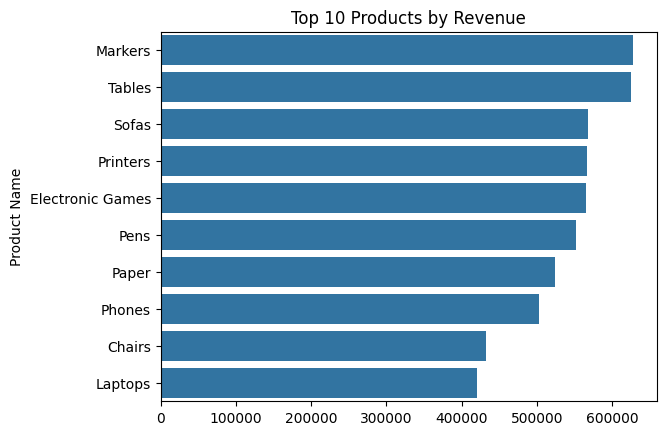

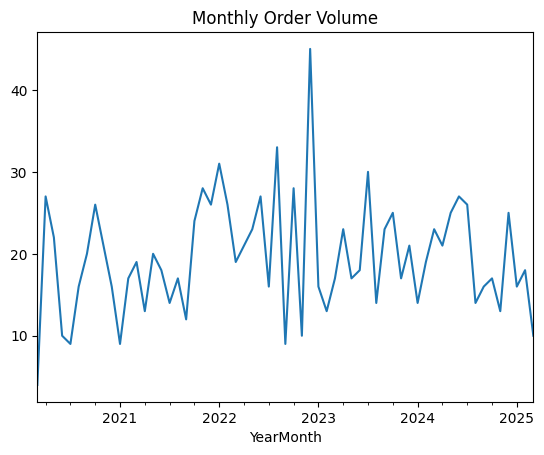

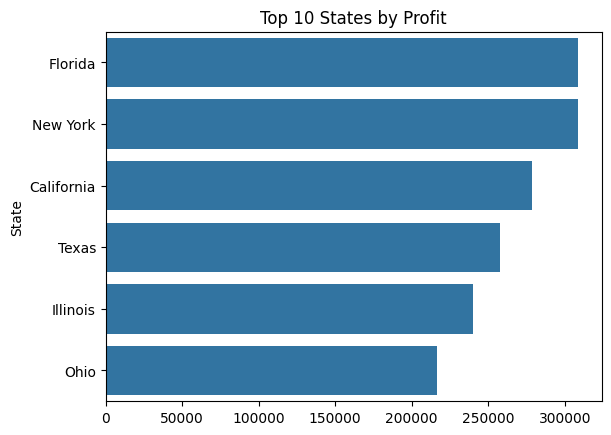

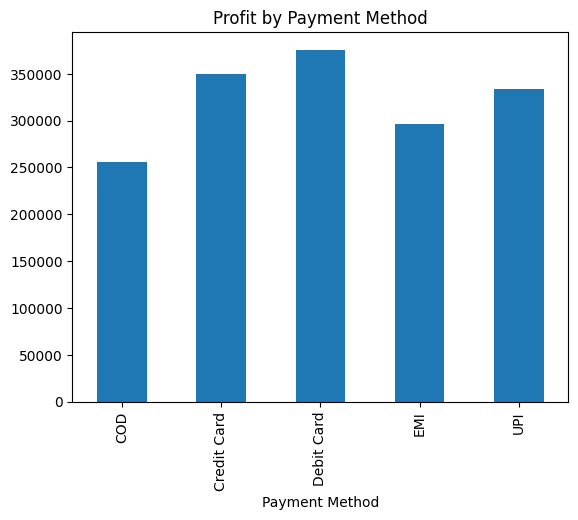


📊 BUSINESS ANALYSIS DASHBOARD
1 Load & Explore Sales Data
2 Clean & Preprocess Data
3 Analyze Payment Methods
4 City-wise Orders
5 Premium Products with Low Sales
6 Visualizations
7 Export Business Reports
0 Exit
Enter choice: 7

✅ Report Exported Successfully

📊 BUSINESS ANALYSIS DASHBOARD
1 Load & Explore Sales Data
2 Clean & Preprocess Data
3 Analyze Payment Methods
4 City-wise Orders
5 Premium Products with Low Sales
6 Visualizations
7 Export Business Reports
0 Exit
Enter choice: 0
Exiting Program


In [ ]:
# ==============================
# BUSINESS PERFORMANCE ANALYSIS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = None


# ==============================
# STEP 1: LOAD & EXPLORE DATA
# ==============================
def load_data():
    global df
    try:
        df = pd.read_csv("sales_data.csv")
        print("\n✅ Dataset Loaded Successfully\n")

        print("First 5 rows:\n")
        print(df.head())

        print("\nColumn Names:\n")
        print(df.columns)

        print("\nData Types:\n")
        print(df.dtypes)

    except FileNotFoundError:
        print("❌ File not found. Please place sales_data.csv in the folder.")


# ==============================
# STEP 2: DATA CLEANING
# ==============================
def clean_data():
    global df

    if df is None:
        print("⚠ Load dataset first")
        return

    print("\nMissing Values:\n")
    print(df.isnull().sum())

    # Convert date column
    if 'Order Date' in df.columns:
        df['Order Date'] = pd.to_datetime(df['Order Date'])

    # Fill numeric missing values
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

    # Fill categorical values
    cat_cols = df.select_dtypes(include='object').columns
    df[cat_cols] = df[cat_cols].fillna("Unknown")

    print("\n✅ Data Cleaning Completed\n")
    print(df.dtypes)


# ==============================
# STEP 3: PAYMENT METHOD ANALYSIS
# ==============================
def payment_analysis():

    if df is None:
        print("⚠ Load dataset first")
        return

    if 'Payment Method' in df.columns:
        result = df['Payment Method'].value_counts()
        print("\nMost Common Payment Methods:\n")
        print(result)
    else:
        print("Payment Method column not found")


# ==============================
# STEP 4: CITY ORDER ANALYSIS
# ==============================
def city_orders():

    if df is None:
        print("⚠ Load dataset first")
        return

    if 'City' in df.columns:
        result = df.groupby('City')['Order ID'].count().sort_values(ascending=False)
        print("\nCities with Highest Orders:\n")
        print(result.head(10))
    else:
        print("City column not found")


# ==============================
# STEP 5: PRODUCT ANALYSIS
# ==============================
def premium_low_sales():

    if df is None:
        print("⚠ Load dataset first")
        return

    product_analysis = df.groupby('Product Name').agg(
        avg_price=('Sales', 'mean'),
        total_quantity=('Quantity', 'sum')
    )

    premium_products = product_analysis[
        (product_analysis['avg_price'] > product_analysis['avg_price'].mean()) &
        (product_analysis['total_quantity'] < product_analysis['total_quantity'].mean())
    ]

    print("\nPremium Products with Low Sales:\n")
    print(premium_products.head(10))


# ==============================
# STEP 6: VISUALIZATIONS
# ==============================
def visualizations():

    if df is None:
        print("⚠ Load dataset first")
        return

    # Top Products by Revenue
    top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

    plt.figure()
    sns.barplot(x=top_products.values, y=top_products.index)
    plt.title("Top 10 Products by Revenue")
    plt.show()


    # Monthly Order Volume
    df['YearMonth'] = df['Order Date'].dt.to_period('M')
    monthly_orders = df.groupby('YearMonth')['Order ID'].count()

    plt.figure()
    monthly_orders.plot(kind='line')
    plt.title("Monthly Order Volume")
    plt.show()


    # Top States by Profit
    state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

    plt.figure()
    sns.barplot(x=state_profit.values, y=state_profit.index)
    plt.title("Top 10 States by Profit")
    plt.show()


    # Profit by Payment Method
    if 'Payment Method' in df.columns:
        payment_profit = df.groupby('Payment Method')['Profit'].sum()

        plt.figure()
        payment_profit.plot(kind='bar')
        plt.title("Profit by Payment Method")
        plt.show()


# ==============================
# STEP 7: EXPORT REPORT
# ==============================
def export_report():

    if df is None:
        print("⚠ Load dataset first")
        return

    # Top products
    top_products = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

    # Monthly orders
    df['YearMonth'] = df['Order Date'].dt.to_period('M')
    monthly_orders = df.groupby('YearMonth')['Order ID'].count()

    combined = pd.concat([top_products, monthly_orders], axis=1)

    combined.columns = ['Top_Product_Revenue', 'Product Name','Monthly_Orders']

    combined.to_csv("top_products_and_monthly_orders.csv",index=False)

    print("\n✅ Report Exported Successfully")


# ==============================
# MENU SYSTEM
# ==============================
while True:

    print("\n📊 BUSINESS ANALYSIS DASHBOARD")
    print("1 Load & Explore Sales Data")
    print("2 Clean & Preprocess Data")
    print("3 Analyze Payment Methods")
    print("4 City-wise Orders")
    print("5 Premium Products with Low Sales")
    print("6 Visualizations")
    print("7 Export Business Reports")
    print("0 Exit")

    choice = input("Enter choice: ")

    if choice == '1':
        load_data()

    elif choice == '2':
        clean_data()

    elif choice == '3':
        payment_analysis()

    elif choice == '4':
        city_orders()

    elif choice == '5':
        premium_low_sales()

    elif choice == '6':
        visualizations()

    elif choice == '7':
        export_report()

    elif choice == '0':
        print("Exiting Program")
        break

    else:
        print("Invalid choice")